In [8]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from src.hyperparameter_tuning import (
    get_best_tuning_summary,
    get_tuning_results,
    plot_train_test_gap,
    plot_tuning_results,
    run_hyperparameter_tuning,
)

In [18]:
df = pd.read_csv('../data/raw/diamonds.csv', index_col=0)

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
)

In [19]:
search = run_hyperparameter_tuning(
    data=train_df,
    target='price',
    n_jobs=2,
    verbose=1,
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [20]:
tuning_results = get_tuning_results(search)

tuning_results.head(10)

,rank_test_score,mean_test_rmse,std_test_rmse,mean_train_rmse,std_train_rmse,mean_fit_time,params
6,1,546.085937,6.416263,428.886576,10.160819,2.569544,"{'model__learning_rate': 0.04, 'model__max_ite..."
20,2,546.146421,6.684246,449.465825,13.653531,0.998405,"{'model__learning_rate': 0.08, 'model__max_ite..."
12,3,546.920772,8.689654,453.283187,10.072138,1.317776,"{'model__learning_rate': 0.06, 'model__max_ite..."
16,4,547.607965,8.195519,463.171243,5.662344,0.799882,"{'model__learning_rate': 0.08, 'model__max_ite..."
14,5,547.771153,5.844011,426.300624,12.539452,2.260103,"{'model__learning_rate': 0.06, 'model__max_ite..."
10,6,547.845800,6.282749,432.274684,9.204128,1.388874,"{'model__learning_rate': 0.06, 'model__max_ite..."
18,7,549.613183,7.574937,417.904037,14.930950,1.195791,"{'model__learning_rate': 0.08, 'model__max_ite..."
4,8,549.926501,8.716758,477.159887,11.208761,1.551240,"{'model__learning_rate': 0.04, 'model__max_ite..."
22,9,550.199268,7.123457,409.907654,20.460511,1.923905,"{'model__learning_rate': 0.08, 'model__max_ite..."
2,10,550.205937,7.492920,461.594117,3.400367,1.614333,"{'model__learning_rate': 0.04, 'model__max_ite..."


In [21]:
get_best_tuning_summary(search)

{'best_cv_rmse': np.float64(546.085936502057),
 'best_params': {'model__learning_rate': 0.04,
  'model__max_iter': 250,
  'model__max_leaf_nodes': 63,
  'model__min_samples_leaf': 20},
 'best_estimator': Pipeline(steps=[('feature_engineering',
                  FunctionTransformer(func=<function apply_selected_feature_engineering at 0x10fb7c900>)),
                 ('preprocessing',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('onehot',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False),
                                                   ['cut', 'color']),
                                                  ('clarity_ordinal',
                                                   OrdinalEncoder(categories=[['I1',
                                                                               'SI2',
    

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Top 10 hyperparameter configurations'}, xlabel='CV RMSE', ylabel='Configuration'>)

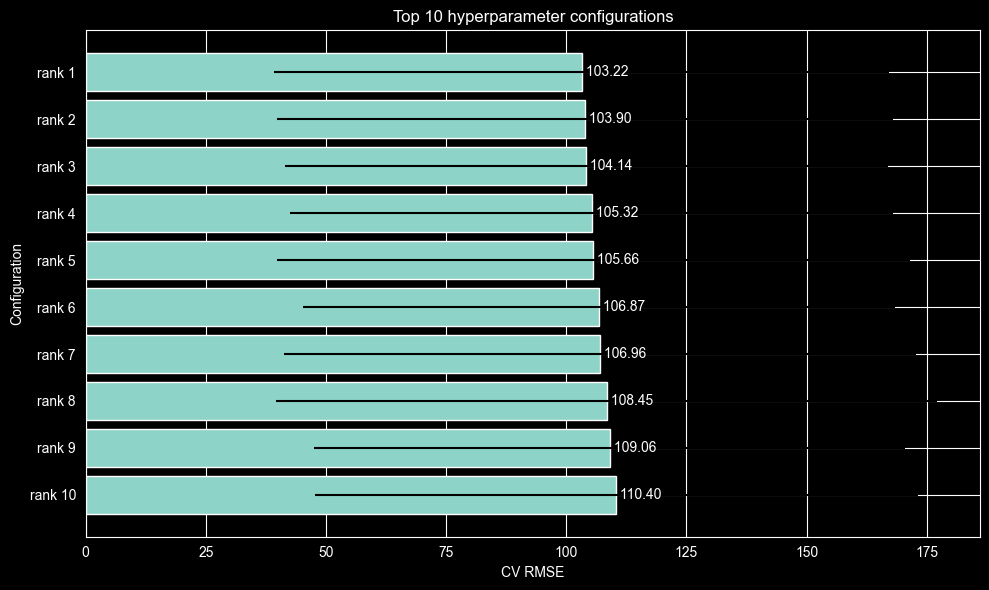

In [13]:
plot_tuning_results(tuning_results, top_n=10)

In [14]:
search.scoring

'neg_root_mean_squared_error'

In [15]:
search.best_score_

np.float64(-103.21606927578505)

In [16]:
get_tuning_results(search).head()

,rank_test_score,mean_test_rmse,std_test_rmse,mean_train_rmse,std_train_rmse,mean_fit_time,params
20,1,103.216069,64.008815,46.721431,3.151283,1.144475,"{'model__learning_rate': 0.08, 'model__max_ite..."
16,2,103.904875,64.140617,49.486933,2.512892,1.161230,"{'model__learning_rate': 0.08, 'model__max_ite..."
21,3,104.140367,62.733409,57.541502,7.293568,1.185001,"{'model__learning_rate': 0.08, 'model__max_ite..."
17,4,105.321054,62.780453,60.622598,8.940573,0.869327,"{'model__learning_rate': 0.08, 'model__max_ite..."
12,5,105.663596,65.826127,47.866149,2.891569,1.317739,"{'model__learning_rate': 0.06, 'model__max_ite..."


In [17]:
train_df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')